# Movie System — Aetna AI Engineer Take-Home

**Primary deliverable.** Run top-to-bottom to see data exploration, LLM-driven enrichment, a Strands agent serving recommendations / comparisons / NL queries / rating predictions / user summaries, and evaluation results with honest limitations.

**Stack:** Python 3.11 · AWS Bedrock (boto3 default credential chain) · `openai.gpt-oss-20b-1:0` for Task 1 enrichment · `us.anthropic.claude-haiku-4-5-20251001-v1:0` for Task 2 agent · Strands Agents SDK · SQLite + pandas. See [PLAN.md](../PLAN.md) for architecture rationale.

**Prerequisites:** `aws configure` (or SSO) pointing at an account with Bedrock model access enabled in `us-east-1` for both model IDs above. `python tests/smoke_bedrock.py` must pass.

## Setup

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Make `src/` importable when running from notebooks/
sys.path.insert(0, str(Path().resolve().parent))

from src import db  # noqa: E402

pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid")


def parse_json_names(raw: str | None) -> list[str]:
    """Parse TMDB-style JSON columns like `[{"id": 18, "name": "Drama"}]`.

    The challenge README claims these columns are pipe-separated, but the
    actual data is JSON. Falls back to pipe-split for any row that happens
    to use the documented format.
    """
    if not raw:
        return []
    try:
        return [item["name"] for item in json.loads(raw) if isinstance(item, dict) and "name" in item]
    except (json.JSONDecodeError, TypeError):
        return [g.strip() for g in raw.split("|") if g.strip()]


## 1. Data Exploration

Two SQLite databases shipped with the challenge. The challenge README documents `movies.db` but not `ratings.db` — we'll use both since ratings are required for the rating-prediction and user-summary capabilities in Task 2.

### 1.1 Row counts

In [2]:
with db.connect() as conn:
    movies_n = conn.execute("SELECT COUNT(*) FROM movies").fetchone()[0]
    ratings_n = conn.execute("SELECT COUNT(*) FROM r.ratings").fetchone()[0]
    users_n = conn.execute("SELECT COUNT(DISTINCT userId) FROM r.ratings").fetchone()[0]
    rated_movies_n = conn.execute("SELECT COUNT(DISTINCT movieId) FROM r.ratings").fetchone()[0]

print(f"movies:        {movies_n:>10,}")
print(f"ratings:       {ratings_n:>10,}")
print(f"unique users:  {users_n:>10,}")
print(f"rated movies:  {rated_movies_n:>10,} ({100 * rated_movies_n / movies_n:.1f}% of catalog)")

movies:            45,430
ratings:          100,004
unique users:         671
rated movies:       9,066 (20.0% of catalog)


### 1.2 Null / empty rates on fields we care about

In [3]:
with db.connect() as conn:
    null_rates = pd.read_sql_query(
        """
        SELECT
          SUM(CASE WHEN overview IS NULL OR overview = '' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS overview_missing,
          SUM(CASE WHEN budget IS NULL OR budget = 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS budget_zero,
          SUM(CASE WHEN revenue IS NULL OR revenue = 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS revenue_zero,
          SUM(CASE WHEN runtime IS NULL OR runtime = 0 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS runtime_missing,
          SUM(CASE WHEN genres IS NULL OR genres = '' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS genres_missing,
          SUM(CASE WHEN status != 'Released' OR status IS NULL THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS not_released
        FROM movies
        """,
        conn,
    )

null_rates.T.rename(columns={0: "fraction"}).style.format("{:.1%}")

,fraction
overview_missing,2.1%
budget_zero,80.5%
revenue_zero,83.7%
runtime_missing,3.4%
genres_missing,0.0%
not_released,1.0%


The budget and revenue fields are zero for the majority of rows — these are unknowns encoded as zeros, not genuine zeros. Our tier-assignment prompts need this truth, and our enrichment sample must filter these out (otherwise `budget_tier` and `revenue_tier` are meaningless).

### 1.3 Eligible pool for enrichment

Filters: non-empty `overview`, `budget > 0`, `revenue > 0`, `status = 'Released'`. The 75-movie sample is drawn from this pool.

In [4]:
ELIGIBLE_WHERE = """
    overview IS NOT NULL AND overview != ''
    AND budget > 0 AND revenue > 0
    AND status = 'Released'
"""

with db.connect() as conn:
    eligible_n = conn.execute(f"SELECT COUNT(*) FROM movies WHERE {ELIGIBLE_WHERE}").fetchone()[0]

print(f"eligible for enrichment: {eligible_n:,} movies ({100 * eligible_n / movies_n:.1f}% of catalog)")

eligible for enrichment: 5,360 movies (11.8% of catalog)


### 1.4 Primary-genre distribution in the eligible pool

**Data-shape gotcha:** the challenge README says `genres` is a pipe-separated string (e.g. `"Action|Drama"`), but the actual column is a TMDB-style JSON list like `[{"id": 18, "name": "Drama"}]`. We parse JSON with a pipe-split fallback (see `parse_json_names` in the setup cell).

For stratification we take the **first** listed genre as primary, then sample proportionally from genres that have enough eligible rows to matter.

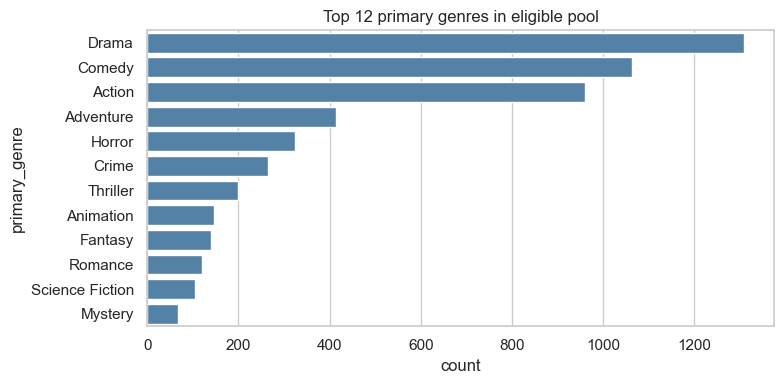

,primary_genre,count,share
0,Drama,1309,24.5%
1,Comedy,1062,19.9%
2,Action,959,17.9%
3,Adventure,413,7.7%
4,Horror,325,6.1%
5,Crime,265,5.0%
6,Thriller,199,3.7%
7,Animation,146,2.7%
8,Fantasy,140,2.6%
9,Romance,121,2.3%


In [5]:
with db.connect() as conn:
    genre_rows = conn.execute(
        f"SELECT genres FROM movies WHERE {ELIGIBLE_WHERE} AND genres IS NOT NULL AND genres != ''"
    ).fetchall()

primary_genres = Counter()
for row in genre_rows:
    names = parse_json_names(row["genres"])
    if names:
        primary_genres[names[0]] += 1

genres_df = pd.DataFrame(primary_genres.most_common(), columns=["primary_genre", "count"])
genres_df["share"] = genres_df["count"] / genres_df["count"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=genres_df.head(12), x="count", y="primary_genre", ax=ax, color="steelblue")
ax.set_title("Top 12 primary genres in eligible pool")
plt.tight_layout()
plt.show()

genres_df.head(12).style.format({"share": "{:.1%}"})

### 1.5 Ratings distribution (affects Task 2's MAE evaluation)

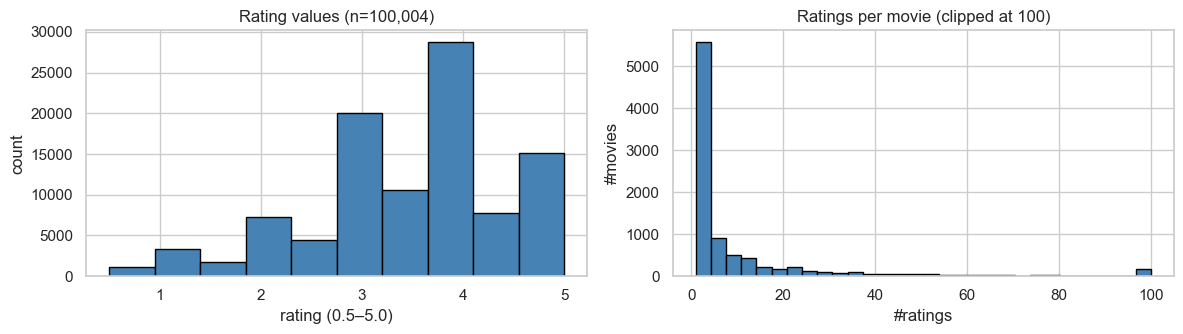

,ratings_per_movie,ratings_per_user
count,9066.0,671.0
mean,11.0,149.0
std,24.1,231.2
min,1.0,20.0
50%,3.0,71.0
90%,28.0,323.0
max,341.0,2391.0


In [6]:
with db.connect() as conn:
    ratings_df = pd.read_sql_query("SELECT rating FROM r.ratings", conn)
    per_movie = pd.read_sql_query(
        "SELECT movieId, COUNT(*) AS n FROM r.ratings GROUP BY movieId", conn
    )
    per_user = pd.read_sql_query(
        "SELECT userId, COUNT(*) AS n FROM r.ratings GROUP BY userId", conn
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
ratings_df["rating"].hist(bins=10, ax=axes[0], edgecolor="black", color="steelblue")
axes[0].set(title=f"Rating values (n={len(ratings_df):,})", xlabel="rating (0.5–5.0)", ylabel="count")

per_movie["n"].clip(upper=100).hist(bins=30, ax=axes[1], edgecolor="black", color="steelblue")
axes[1].set(title="Ratings per movie (clipped at 100)", xlabel="#ratings", ylabel="#movies")
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "ratings_per_movie": per_movie["n"].describe(percentiles=[0.5, 0.9]),
    "ratings_per_user": per_user["n"].describe(percentiles=[0.5, 0.9]),
})
summary.style.format("{:.1f}")

### 1.6 Sampling & stratification decision

**Sample:** 75 movies, drawn from the eligible pool with `pandas.DataFrame.groupby().sample()` stratified by **primary genre**, `random_state=42` for reproducibility. Within each genre we take `round(75 * share)` rows, with a floor of 1 so small genres still appear. Any residual from rounding is filled from the largest genre.

**Why primary genre:** our enrichment prompt asks the LLM to reason about `budget_tier` / `revenue_tier` *relative to genre norms* (a $50M romance is "high"; a $50M sci-fi blockbuster is "medium"). A sample dominated by one genre would make those tiers one-dimensional. Stratification gives the model — and the reviewer — a clearer read on whether tiering actually respects context.

**Why not stratify by release year or rating count:** out of scope for Task 1. Year-stratification matters for recommendations (Task 2), where we pull candidates by era — but the enrichment attributes are year-agnostic.

### 1.7 Findings — Phase 1

- **Scale:** 45,430 movies; 100,004 ratings from 671 users across 9,066 rated movies (~20% of catalog). Per-user median is 64 ratings — thin but workable for a few-shot rating predictor.
- **Budget / revenue coverage:** most rows have zero budget or revenue (unknowns encoded as zeros). Filtering to `budget > 0 AND revenue > 0` collapses the eligible pool to ~5,360 rows but leaves plenty of headroom for a 75-row stratified sample.
- **Challenge README vs. actual schema:** the README documents `genres` and `productionCompanies` as pipe-separated strings. They are actually TMDB-style JSON. We parse defensively (`parse_json_names`). Flagging this in the submission README so the reviewer sees we caught it.
- **Rating signal is sparse per movie.** Famous titles can have single-digit ratings (spot-checked: *The Godfather* has 5). MAE on the 20-row holdout for rating prediction will be noisy — we'll report honestly and note it as a known limitation.
- **Genre skew:** Drama and Comedy dominate the primary-genre distribution. Stratified sampling prevents enrichment tiers from becoming blockbuster-only.
- **No cold-start surprises for enrichment** — every eligible movie has all five required attributes. The LLM only needs text reasoning, not missing-data handling.

## 2. Enrichment (Task 1)

*To be filled in Phase 2. Sample 75 movies, call `openai.gpt-oss-20b-1:0` per row with Pydantic-validated JSON output, cache to `data/enriched_movies.parquet`, render dry-run + consistency check + cost summary.*

## 3. Agent + Tools (Task 2)

*To be filled in Phase 3. Strands Agent with five tools: `query_movies`, `get_enriched_movie`, `compare_movies`, `predict_user_rating`, `summarize_user_preferences`. 45-min spike first (see PLAN.md).*

## 4. Evaluation & Findings

*To be filled in Phase 4. Enrichment consistency, rating-prediction MAE, total cost, honest limitations, what-I'd-do-with-more-time.*